/home/student/Pulpit/valeriia/.venv/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


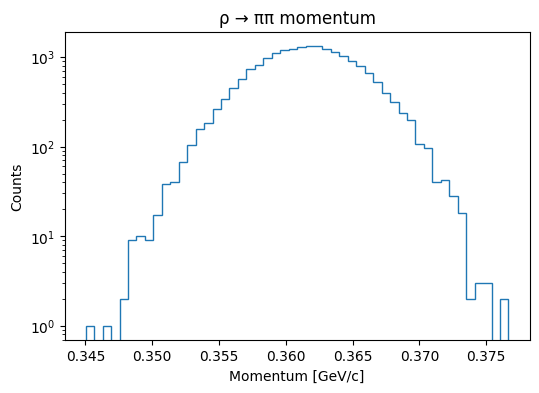

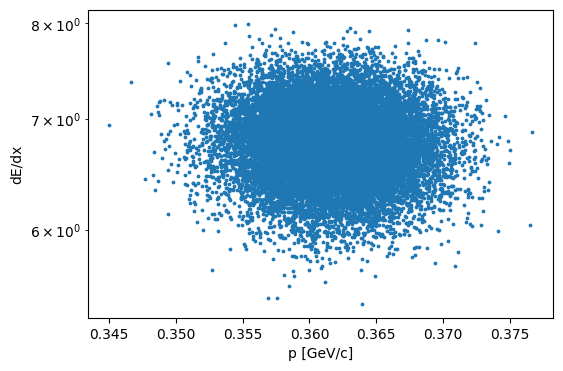

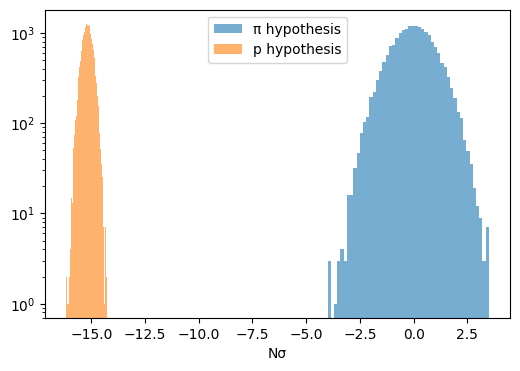

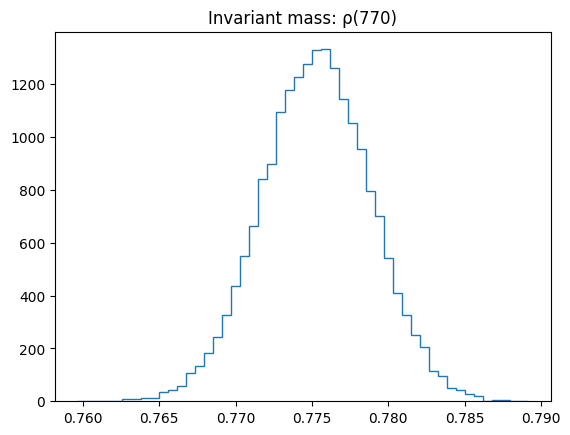

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# 1. TWO-BODY DECAY MOMENTUM (at rest)
# -------------------------------------------------------------

def P_two_body(M, m1, m2):
    """Relativistic two-body decay momentum."""
    term = (M**2 - (m1 + m2)**2)*(M**2 - (m1 - m2)**2)
    p = np.sqrt(term) / (2*M)
    return p

# -------------------------------------------------------------
# 2. RANDOM ISOTROPIC ANGLES
# -------------------------------------------------------------

def angles():
    phi = np.random.uniform(0, 2*np.pi)
    costheta = np.random.uniform(-1, 1)
    theta = np.arccos(costheta)
    return phi, theta

def momentum_vectors(p, phi, theta):
    px = p * np.sin(theta) * np.cos(phi)
    py = p * np.sin(theta) * np.sin(phi)
    pz = p * np.cos(theta)
    return np.array([px, py, pz])

# -------------------------------------------------------------
# 3. UNIVERSAL TWO-BODY GENERATOR
# -------------------------------------------------------------

def generator(M, m1, m2):
    """Particle of mass M decays at rest into daughters m1, m2."""
    p = P_two_body(M, m1, m2)
    phi, theta = angles()
    p1 = momentum_vectors(p, phi, theta)
    p2 = -p1
    return p1, p2

# -------------------------------------------------------------
# 4. BETA AND BETHE-BLOCH
# -------------------------------------------------------------

def beta(p, m):
    return p / np.sqrt(p**2 + m**2)

def bethe_bloch(p, m):
    a, b, c = 2.0, 4.0, 0.05
    β = beta(p, m)
    val = a/β**2 * (b - β**2 - np.log(c + 1/β**2))
    return np.maximum(val, 0.1)

TPC_dEdx_resolution = 0.05

def measure_dEdx(p, m):
    true = bethe_bloch(p, m)
    smeared = np.random.normal(true, TPC_dEdx_resolution*true)
    return smeared

def nsigma_pid(dEdx_meas, p, mass_hypothesis):
    expected = bethe_bloch(p, mass_hypothesis)
    sigma = TPC_dEdx_resolution * expected
    return (dEdx_meas - expected) / sigma

# -------------------------------------------------------------
# 5. MOMENTUM SMEARING (ALICE-LIKE)
# -------------------------------------------------------------

def smear_momentum(p_vec):
    p = np.linalg.norm(p_vec)
    sigma_rel = np.sqrt(0.01**2 + (0.01*p)**2)
    p_smeared = np.random.normal(p, sigma_rel*p)
    return p_smeared * (p_vec/p) if p > 0 else p_vec

# -------------------------------------------------------------
# 6. MASSES
# -------------------------------------------------------------

masses = {
    'pion':   0.13957,
    'muon':   0.10566,
    'kaon':   0.49368,
    'proton': 0.93827,
    'rho':    0.77526,
    'jpsi':   3.0969,
    'psi2s':  3.6861
}

# -------------------------------------------------------------
# 7. SPECIFIC DECAY MODES
# -------------------------------------------------------------

def rho2pi():
    return generator(masses['rho'], masses['pion'], masses['pion'])

def jpsi2muon2():
    return generator(masses['jpsi'], masses['muon'], masses['muon'])

def psi2s2muon2():
    return generator(masses['psi2s'], masses['muon'], masses['muon'])

def pp_interaction():
    return generator(masses['proton'], masses['proton'], masses['proton'])

def gg2ll(m_gamma, m1, m2):
    """Exclusive γγ → l+l−."""
    return generator(m_gamma, m1, m2)

# -------------------------------------------------------------
# 8. EVENT GENERATOR
# -------------------------------------------------------------

def event_generator(decay, N=10000):
    momentum = []
    invariant_mass = []
    dedx_meas = []
    nsig_pi = []
    nsig_p = []

    for _ in range(N):

        if decay == "jpsi":
            p1, p2 = jpsi2muon2()
            daughter_mass = masses['muon']
            parent_mass = masses['jpsi']

        elif decay == "psi2s":
            p1, p2 = psi2s2muon2()
            daughter_mass = masses['muon']
            parent_mass = masses['psi2s']

        elif decay == "rho":
            p1, p2 = rho2pi()
            daughter_mass = masses['pion']
            parent_mass = masses['rho']

        elif decay == "pp":
            p1, p2 = pp_interaction()
            daughter_mass = masses['proton']
            parent_mass = masses['proton']

        elif decay == "gg→mumu":
            p1, p2 = gg2ll(0, masses['muon'], masses['muon'])
            daughter_mass = masses['muon']
            parent_mass = 0

        else:
            raise ValueError("Unknown decay")

        # momentum smearing
        p1_s = smear_momentum(p1)
        p = np.linalg.norm(p1_s)

        # dE/dx measurement
        dEdx = measure_dEdx(p, daughter_mass)

        # PID hypotheses
        nsig_pi.append(nsigma_pid(dEdx, p, masses['pion']))
        nsig_p.append(nsigma_pid(dEdx, p, masses['proton']))

        # invariant mass
        E1 = np.sqrt(np.linalg.norm(p1_s)**2 + daughter_mass**2)
        E2 = np.sqrt(np.linalg.norm(p2)**2 + daughter_mass**2)

        p4 = np.array([E1 + E2, *(p1_s + p2)])
        m_inv = np.sqrt(max(p4[0]**2 - np.linalg.norm(p4[1:])**2, 0))

        invariant_mass.append(m_inv)
        momentum.append(p)
        dedx_meas.append(dEdx)

    return (np.array(momentum),
            np.array(invariant_mass),
            np.array(dedx_meas),
            np.array(nsig_pi),
            np.array(nsig_p))

# -------------------------------------------------------------
# 9. QA PLOTS
# -------------------------------------------------------------

def qa_plot_momentum(p, title):
    plt.figure(figsize=(6,4))
    plt.hist(p, bins=50, histtype='step')
    plt.xlabel("Momentum [GeV/c]")
    plt.ylabel("Counts")
    plt.title(title)
    plt.yscale("log")
    plt.show()

def qa_plot_dedx(p, dE):
    plt.figure(figsize=(6,4))
    plt.scatter(p, dE, s=3)
    plt.xlabel("p [GeV/c]")
    plt.ylabel("dE/dx")
    plt.yscale("log")
    plt.show()

def qa_plot_nsigma(nsig_pi, nsig_p):
    plt.figure(figsize=(6,4))
    plt.hist(nsig_pi, bins=50, alpha=0.6, label="π hypothesis")
    plt.hist(nsig_p, bins=50, alpha=0.6, label="p hypothesis")
    plt.legend()
    plt.xlabel("Nσ")
    plt.yscale("log")
    plt.show()

# -------------------------------------------------------------
# 10. EXAMPLE RUN
# -------------------------------------------------------------

mom_rho, m_rho, d_rho, nsig_pi_rho, nsig_p_rho = event_generator("rho", N=20000)

qa_plot_momentum(mom_rho, "ρ → ππ momentum")
qa_plot_dedx(mom_rho, d_rho)
qa_plot_nsigma(nsig_pi_rho, nsig_p_rho)

plt.hist(m_rho, bins=50, histtype='step')
plt.title("Invariant mass: ρ(770)")
plt.show()
